 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Sebastian Szmytka                <br>
Student Number : L 00196514        <br>
Due Date       : 12th May 2359hrs                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs

## Imports

In [1]:
# imports basics + text and analysis
import os
import spacy
from spacy import displacy
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
import cv2
import pytesseract
from pytesseract import Output
import pymupdf
import sys
import re
print(sys.executable)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import scattertext as sct

# additional imports for CV
from matplotlib import pyplot as plt
import cv2

%matplotlib inline

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3


In [2]:
# test
print("cv2", cv2.__version__)
print("pytesseract", pytesseract.__version__)

cv2 4.13.0
pytesseract 0.3.13


# Support Functions

### Tools

In [4]:
def load_files(folder_path, extensions=None):
    """
    Loop to return a list of full file paths from a folder
    """
    files = []
    for root, dirs, filenames in os.walk(folder_path):
        for fname in filenames:
            _, ext = os.path.splitext(fname)
            if extensions is None or ext.lower() in extensions:
                files.append(os.path.join(root, fname))
    
    files = sorted(files)
    print(f"Found {len(files)} files in '{folder_path}'")
    return files
    
def check_fileformat(filepath):
    """
    function to validate file format example if its an image or a pdf file
    1. checks if file exists
    2. identify the extention
    3. make decision based on the file format and process it
    """

    if not os.path.isfile(filepath):
        return f"Error: file not found: {filepath}"

    fileextension = os.path.splitext(filepath)[1].lower()

    print(fileextension)

    try:
        if fileextension == '.pdf':
            print("file type: ", fileextension)
            return pdf_tostring(filepath)
        elif fileextension in [".bmp",".jpg",".png",".tiff",".jpeg"]:
            print("file type: ", fileextension)
            return image_tostring(filepath)
        else:
            print("Unsupported format: ", fileextension)

    except Exception as e:
        return f"An error occurred: {e}"

### Functions for NLP

In [32]:
# Support functions
def clean_text(text):
    text = text.lower()
    # remove numbers/symbols
    text = re.sub(r'[^a-z\s]', '', text)
    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

def extract_text(img_path, conf_threshold=60):
    """
    function with improved Tesseract to deal with bad quality of an image

    """
    img = cv2.imread(img_path)
    d = pytesseract.image_to_data(img, config=r'--oem 3 --psm 6', output_type=Output.DICT)
    words = [d['text'][i] for i in range(len(d['text']))
             if int(d['conf'][i]) > conf_threshold and d['text'][i].strip()]
    return ' '.join(words)

def create_lemmatization(text_to_convert):
    text_to_convert = nlp(text_to_convert)
    for token in text_to_convert:
        print (f"{token.text:{15}} {token.lemma_:{30}}")
    

def create_tokenize(text_token):
    nlp = spacy.load("en_core_web_sm")
    text_token = nlp(text_token)
    for token in text_token:
        print (token.text, token.pos_, end = " | ")

    print("\n\n Number of tokens: ", len(nlp_sentence))



def image_tostring(img):
    """
    image to string function + image to boxes
    """
    print(f"\n image_tostring received: '{img}'")  
    print(f"\n repr: {repr(img)}")                 

    img = cv2.imread(img)
    
    if img is None:
        return f"Error: could not read image"
    
    h, w, c = img.shape
    print(img.shape)

    # draw bounding boxes around detected characters
    boxes = pytesseract.image_to_boxes(img)
    for i in boxes.splitlines():
        i = i.split(' ')
        img = cv2.rectangle(img, (int(i[1]), h - int(i[2])), (int(i[3]), h - int(i[4])), (0, 255, 0), 2) 
        
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Convert image to string
    custom_config = r'--oem 3 --psm 6' # changed for better results
    txt = pytesseract.image_to_string(img, config=custom_config)
    print(txt)
    return txt
    
def pdf_tostring(pdf):
    """
    pdf to string function convers pdf to png file
    returns string/text
    """
    doc = pymupdf.open(pdf)
    st = ""
    output_folder = "samples/png_outputs/"
    os.makedirs(output_folder, exist_ok=True)
    # if the pdf has multiple pages this for loop can be edited to accommodate
    for page in doc:
        # setting the dpi to 300 for higher quality image - this can be set higher
        img = page.get_pixmap(dpi=300)
        #Saving the image to local drive where it can be accessed again
        path = os.path.join(output_folder, f"pdf{page.number}.png")
        print("\n Saving to path: ", path)
        print("\n Path type: ", type(path))
        img.save(path)

        print("\n File exists after save: " ,os.path.isfile(path))
        
        txt = image_tostring(path)
        
        #adding txt to one final string
        st += txt
    return st
    

## Functions for Vision

### Section 2.1

In [12]:
def imgaddtext(img, text='TEST', org=(50,50), fontscale=3, color=(0,0,0), thickness=5):
    """
    Function to add text overlay onto an image
    """
    if isinstance(img, str):
       img = cv2.imread(img)
       img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    font = cv2.FONT_HERSHEY_COMPLEX
    cv2.putText(img, text=text, org=org, fontFace=font, fontScale=fontscale, color=color, thickness=thickness)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111)
    ax.imshow(img)
    plt.show()
    
def img_process(img):

    """
    function to present section 2.1 Image processing
    """

    print("\n Grayscale using OpenCV \n")
    bwimg = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
    print("image resolution: ",bwimg.shape)
    
    print("confirms conversion to NumPy array",type(bwimg))

    plt.imshow(bwimg,cmap="gray")
    plt.show()

  
    # BGR / img is the numpy array, where each pixel contains 3 numbers (B, G, R).
    bgrimg = cv2.imread(img)
    print("\n BGR - three color chanel using OpenCV \n")
    print("to confirm three color chanel: ",bgrimg.shape)
    # This uses Matplotlib to display the image.
    plt.imshow(bgrimg)
    plt.show()

    print("\n COLOR CHANELLS (R + G + B) \n")

    img = cv2.imread(img)
    
    # make a copy of the image
    img_red = img.copy()
    
    # Just show the red channel
    img_red[:, :, 1] = 0    # Zero out contribution from green
    img_red[:, :, 2] = 0    # Zero out contribution from blue
    plt.imshow(img_red)
    plt.show()
    
    img_green = img.copy()
    
    # Just show the red channel
    img_green[:, :, 0] = 0    # Zero out contribution from red
    img_green[:, :, 2] = 0    # Zero out contribution from blue
    plt.imshow(img_green)
    plt.show()
    
    img_blue = img.copy()
    # Just show the blue channel
    img_blue[:, :, 0] = 0    # Zero out contribution from red
    img_blue[:, :, 1] = 0    # Zero out contribution from green
    plt.imshow(img_blue)
    plt.show()

def rgbtobgr1(img):
    """
    function to convert RGB to BGR method 1
    """
    img = cv2.imread(img)

    print("\n Method 1: Using cv2.cvtColor \n")
    # COLOR_BGR2RGB swaps the Blue and Red channels
    imgrgb_method1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(imgrgb_method1)
    plt.axis("off")
    plt.show()

def rgbtobgr2(img):
    """
    function to convert RGB to BGR method 2
    """
    img = cv2.imread(img)
    print("\n Method 2: NumPy array slicing \n")
    # [:,:,::-1] reverses the order of the colour channels
    imgrgb_method2 = img[:,:,::-1]
    plt.imshow(imgrgb_method2)
    plt.axis("off")
    plt.show()

def imgexpand(img,x=2, y=2):

    # Expanding: x - horizontal, y - vertical
    # default to double the size
    
    img = cv2.imread(img)
    res = cv2.resize(img, None,fx=x, fy=y, interpolation = cv2.INTER_CUBIC)
    plt.imshow(res)
    plt.show()

def imgshrink(img,x=0.3, y=0.3):
    
    # Shrinking: x - horizontal, y - vertical
    # default to 0.3 = 30%
    img = cv2.imread(img)
    res = cv2.resize(img, None,fx=x, fy=y, interpolation = cv2.INTER_CUBIC)
    plt.imshow(res)
    plt.show()
    
def imgrotate(img, angle=25, scale=0.5, display=True):
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get image dimensions
    (h, w) = img.shape[:2]
    
    # Define center of rotation
    center = (w // 2, h // 2)
    
    # Generate 2x3 rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, scale)
    
    # Apply affine transformation
    rotated = cv2.warpAffine(img, M, (w, h))
    
    if display:
        plt.imshow(rotated)
        plt.axis("off")
        plt.show()
    
    return rotated


def imagethresholding(img):
    
    img = cv2.imread(img)
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Thresholding
    ret,thresh1 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)
    ret,thresh2 = cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)
    ret,thresh3 = cv2.threshold(img_gray,127,255,cv2.THRESH_TRUNC)
    ret,thresh4 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO)
    ret,thresh5 = cv2.threshold(img_gray,127,255,cv2.THRESH_TOZERO_INV)
    
    titles = ['Original Image','Binary','Binary INV','TRUNC','TOZERO','TOZERO_INV']
    images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
    
    for i in range(6):
        plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
        plt.title(titles[i])
        plt.xticks([]),plt.yticks([])
    
    plt.show()

def imgblur(img, method='gaussian',blurkrl=(15,15), gauskrl=(9,9)):

    # Blurring from lab example just turned to function

    img = cv2.imread(img)
    imgrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

   # plt.imshow(imgrgb)
   # plt.title('Original')
   # plt.axis("off")
   # plt.show()

    if method == 'standard':
        result = cv2.blur(imgrgb, blurkrl)
        plt.title('Standard Blur')
    elif method == 'gaussian':
        result = cv2.GaussianBlur(imgrgb, gauskrl, 0)
        plt.title('Gaussian Blur')
    else:
        print("ERROR - use 'standard' or 'gaussian'")
        return

    plt.imshow(result)
    plt.axis("off")
    plt.show()


### Section 2.2

In [13]:
def imgcontours(img, tx = 127, mode=cv2.RETR_TREE, br=2):
    """
    Function to detect/draw contours on an image
  
    """
    # convert to gray scale
    img_gray = cv2.imread(img, 0)
    
    # load colour version for display
    img_colour = cv2.imread(img)
    img_colour = cv2.cvtColor(img_colour, cv2.COLOR_BGR2RGB)
    
    # apply binary threshold - contours work best on binary images
    ret, thresh = cv2.threshold(img_gray, tx, 255, cv2.THRESH_BINARY)
    
    # find contours
    contours, hierarchy = cv2.findContours(thresh, mode, cv2.CHAIN_APPROX_SIMPLE)
    
    # draw contours on colour image in green
    imgcontour = cv2.drawContours(img_colour.copy(), contours, -1, (0, 255, 0), br)
    
    print(f"\n Number of contours detected: {len(contours)}")
    
    plt.imshow(imgcontour)
    plt.title(f'Contours detected: {len(contours)}')
    plt.axis("off")
    plt.show()

def imgedges(img,x=15, y=15):
    """
    Function to detect edges using Sobel and Laplacian operators
    """
    # load as grayscale - consistent with lab approach
    img = cv2.imread(img, 0)

    sobelx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=x)
    sobely = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=y)
    laplacian = cv2.Laplacian(img, cv2.CV_32F)

    fig = plt.figure(figsize=(15, 20))
    ax1 = fig.add_subplot(1, 3, 1)
    plt.title('Sobel X')
    ax1.imshow(sobelx, cmap='gray')
    ax2 = fig.add_subplot(1, 3, 2)
    plt.title('Sobel Y')
    ax2.imshow(sobely, cmap='gray')
    ax3 = fig.add_subplot(1, 3, 3)
    plt.title('Laplacian')
    ax3.imshow(laplacian, cmap='gray')
    plt.show()

### Section 2.3

In [14]:
def imgwatershed(img):
    """
    Function to segment an image using the Watershed algorithm
    """
    img_array = cv2.imread(img)
    imgrgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    # existing blur function for preprocessing
    img_blur = cv2.medianBlur(imgrgb, 59)
    
    #  grayscale conversion
    gray = cv2.cvtColor(img_blur, cv2.COLOR_BGR2GRAY)

    # threshold approach consistent with imgcontours
    ret, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((3,3), np.uint8)
    sure_bg = cv2.dilate(thresh, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown==255] = 0
    markers = cv2.watershed(imgrgb, markers)

    # imgcontours logic for drawing results
    contours, hierarchy = cv2.findContours(markers.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    for i in range(len(contours)):
        if hierarchy[0][i][3] == -1:
            cv2.drawContours(imgrgb, contours, i, (255,0,0), 2)

    print(f"\n Segments detected: {len(contours)}")
    plt.imshow(imgrgb)
    plt.axis("off")
    plt.show()

def imgcanny(img, blur_krl=(5,5)):
    """
    Function to detect edges using Canny Edge Detection

    """
    img = cv2.imread(img)
    imgrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # calculate median pixel value for threshold - lab approach
    medianval = np.median(img)
    print(f"\n Median value: {medianval}")

    # apply blur before canny - reduces noise and improves edge detection
    blurred = cv2.blur(imgrgb, ksize=blur_krl)

    # apply canny edge detection
    edges = cv2.Canny(image=blurred, threshold1=medianval, threshold2=255)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(imgrgb)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title(f'Canny Edges - blur kernel {blur_krl}')
    axes[1].axis('off')
    plt.show()

### Section 2.4

In [15]:
def imgenhancment(img, y=21):
    """
    Function for image enhancement
    """
    if y % 2 == 0 or y > 31:
        print(f"Invalid kernel size resetting to 21")
        y = 21

    # load colour and grayscale versions
    img_bgr = cv2.imread(img)
    imgrgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # sobel Y edge detection
    sobely = cv2.Sobel(img_gray, cv2.CV_32F, 0, 1, ksize=y)
    sobely = cv2.normalize(np.absolute(sobely), None, 0, 255, cv2.NORM_MINMAX)
    sobely = np.uint8(sobely)

    # binary inverse threshold
    ret, thresh_inv = cv2.threshold(sobely, 127, 255, cv2.THRESH_BINARY_INV)

    # blend to sharpen
    thresh_rgb = cv2.cvtColor(sobely, cv2.COLOR_GRAY2RGB)
    sharpened = cv2.addWeighted(imgrgb, 1.2, thresh_rgb, 0.3, 0)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    # display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(imgrgb)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(sobely, cmap='gray')
    axes[1].set_title('Sobel Y')
    axes[1].axis('off')
    axes[2].imshow(sharpened)
    axes[2].set_title('Sharpened')
    axes[2].axis('off')
    plt.show()

    # histogram comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    color = ('r', 'g', 'b')
    for i, col in enumerate(color):
        ax1.plot(cv2.calcHist([imgrgb], [i], None, [256], [0, 256]), color=col)
        ax2.plot(cv2.calcHist([sharpened], [i], None, [256], [0, 256]), color=col)
    ax1.set_title('Original Histogram')
    ax1.set_xlim([0, 256])
    ax2.set_title('Sharpened Histogram')
    ax2.set_xlim([0, 256])
    plt.show()

# NLP

## Text Extraction end Processing (OCR)


 Current Directory: /Users/sebszmytka/GIT_NLP/ca2-assignment-lightarchivist-1

.pdf
file type:  .pdf

 Saving to path:  samples/png_outputs/pdf0.png

 Path type:  <class 'str'>

 File exists after save:  True

 image_tostring received: 'samples/png_outputs/pdf0.png'

 repr: 'samples/png_outputs/pdf0.png'
(3301, 2551, 3)


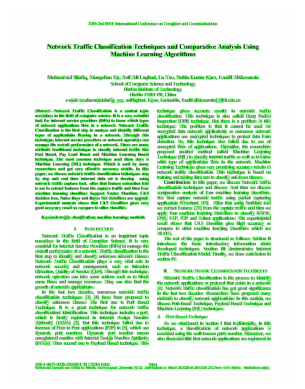

20116 2nd MABE linfsnoatiional Oonfiansnce on Oomypiitien and Oonotiimniicatiions
Network! Diaffic Classification Nechniiques and Coniparative Aljalysis
Machine earning Algorithms
Shalfig, Xitangzhian Yity AlsiiflAlli Daghianil, (Oo ‘Yao, Niabiin Kicniam Keon, loudill Albldessannia
Schoo! of Con@jatén Science anid Nechinology,
Hiaecbin Iiiitifate of Nechinology,
Harbin 15001 PR), China
e-nhiaili (jmubanmhadshatiq, yw asiflaghari, Lfjao, Karhisabin, fsudiDdbdessamiall @hit.eda.cn

bstroci—Netwonk Minaftic Olassifibation is a cenfnal fopic fechnique gives @ccurafe resolts jin mefvabrk) traffic
nowadays in the field off cofayhten scien: If is a weny essénfial  classilfiivation. (Ohis technique is also called Deep Padket
faski fon infennef service providers (ISPs) fo Know which fypes {inspection (DPI) technique. Bint there fis a problem in this
of nefwork ayiplicatiions flaw in a oefwork, Network Mbaffic fechnique] The problem is hat iif cannof be used fon
Olassiffication is the finst stép

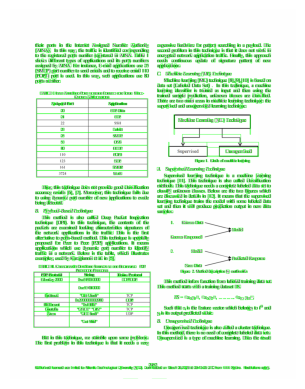

thein ports fin the Mnferitf Assigned Nombén Alnthorify expensive hardware fin paftieri seanchiing in a payload, Nhe
(AINA)! On this way the traiffic fis identilfiéd corfesponding second problem iin this fechinigire fis that if does not wrk inl
fo the registered pots muntien jtegistened ini AINA! Wible 1 = encrypted network! application trafic. Pinallly, thils approach
shows different types of! applications and jifs ports numibers needs continuous update off signature patie off mew
assigned by AINA) Hon instance, B-niail applications use 28  apyplications:
(SMIDP) port muntiben fo send entails and fo necellve entail 1 10 Wikia
(POPS) port is used. In this way, web applications use BO u a ions tL usp 89100) a
nahiber que S on
eal data set (Labelled Dafa Sef) . fn this technique, a machine
— learning olassilfiien is as input and then using the
Fee ee eT ee ELSIE Soe WELD trained sone freficion, onkincxsn Glasses are Sis
(heirs ans areas iin o@aéhine learning fechiniicq)
cope eel ar] unsi

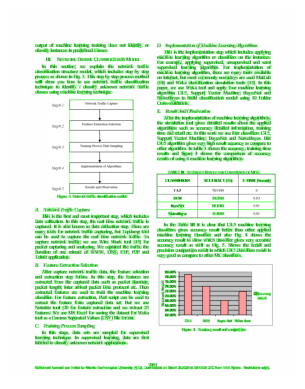

outpot of} machine ledrniing fraiining does not identify on D. Implementation of Machine Dearing Algorithms
nmichine learhing algorithm on on iinsfarides)
Ol. = INSDWORK DRABEIO OOASSIFICATION MODDED Fon ia ving) 8 fel, OnE ised] andl semi
In this section! we explain the nefwork traffic gqpenvised learhing Algoriffiin. Fon implenigntation off
Classifiitation stracturé model, which inclodes sfep by step nace learning algorithm, there ane many, idols available
prowess as shown iin Big. 3. (his step by sfep process method — op jinfétnet, bot most cdrmonly nowadays are used Matab
willl show you how fo use oetvzrk! Classification — (14) and Wikkal blasSifficatiion simulation fools (IG). lin this
technique to identify 2 classify) unknown netvabrh) Gafic = papen, we ose Wika fool and appily) fon madhine learning,
classes using michiiie lledrhing techinigiie: algoritfiin O4.5, Supporf Vecton Machine} BiayesNet and
NéiveBayes fo bitild classification model using 10 Holden
AL Result And Obsdrvat

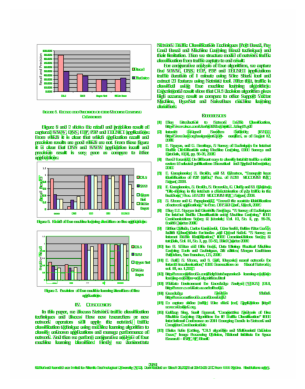

Neétvzbrk (Tiafific Olassilfiization Dechniques (Pai Biased, Pay,

100.0% oad Based and Mitchiine Uearning Based technique) and

6 004 thein limitation. Then we stnactane modeé] of) netwibrk thaffic
3 ons classification fhom trafiis capture fo end nésullo

& mos hon comparative adalysis off foun algonithms, we captone
2 some Gieral fivd WWW, DNS] ADP, PSP and THUNB applications
= wu Wfiecsion | (Walia duratich off 1 mimufe using Wine Shark fool and

© s0.00% a , = 7

© oom extract 23 feafunes using Netnimite fool. Alfien tat, traffic iis

re Classified usiti foun machine learning algonithris

one Bxperinizntal nesulli shiow thi 04.8 decision allgonithin gives
oan am Boge en SE Basa high accuracy, resulli as compare fo offen Supporti Vietton
Machine, BiyesNef and NaiveBiaes rhachiine ledtining
Clasbilfiens
RIGORE 6. RIEOADD GND PREDISION OF FOUR MADEN DESRNING
OnASSIRIBRS IREEERENOBS
(0) Qhoy nfimodoctio# fo  (Nefwork) Qlassificatiion,

Higare 6 and (7 shows the ré&vall and pretision re

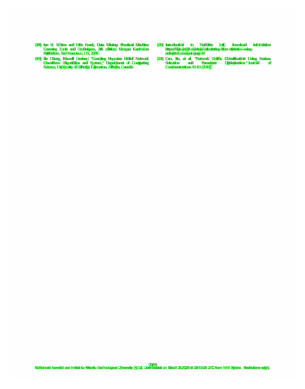

(U8) tan A. Mitten and Bibe Brank, Data Miinings Piactical Machine [20] Intmodoction to  NetMafe fol!) download  infbrination
Deaniing Mools anid Mechniiqaes, edition) Miongan Kanfirignn hittpsd//dan acoktt.ca/niiny/ calcolating-fiiwr-Sigtiistiios-usiing-
Piibfishiens, Sah Brancisoo, OAl, 2005) neiniate/conmint=page3 00

(09) Gie Oheng, Ritssell Greiner) “Dearing Bayesian Belief) Network  {2Il] Oao, lie, ef al. “Network [tific Olassilfication Using Reatone
Qassifies: Algonitiiqns and System," Deparfinent off Conipoting Selection and a Optiniization.” Gouirial off)
Science, Unhviensity of Allberizd Edinonton, Allbeiita, Oanadéo Oonirhonicatiions 10.00 (200

ABiofced loendd ase Omited tai Aandi DecGoologioal (iisersiy (NO, Oo Zabshes on Mino 08,20 a OOS OO feo IBGE Bc, Restrictions agiply.

20116 2nd MABE linfsnoatiional Oonfiansnce on Oomypiitien and Oonotiimniicatiions
Network! Diaffic Classification Nechniiques and Coniparative Aljalysis
Machine earning Algorithms
Shalfig, Xitangzhian

In [33]:
## code
# test of file format function

cwd = os.getcwd()
print(f"\n Current Directory: {cwd}\n")
file1 = "KaggleDataset/images/0.jp "
file2 = "samples/pdf/Network_3.pdf"

st = check_fileformat(file2)

st_full = st

# just to make it tidier i will limit the amout of text to make the outputs cleaner

st = "\n".join(st.split("\n")[:10])

# print(st)

print(st_full)


## Text Cleaning

### Tokenisation
segmenting sentences in to units called "tokens"

In [34]:
# tokenisation - load english language library

nlp = spacy.load("en_core_web_sm")


In [35]:
# process and show tokens
nlp_sentence = nlp(st)

for token in nlp_sentence:
    print (token.text, token.pos_, end = " | ") # sentence use and separation

# counting tokens
print("\n\n Number of tokens: ", len(nlp_sentence))

20116 NUM | 2nd ADJ | MABE ADJ | linfsnoatiional ADJ | Oonfiansnce PROPN | on ADP | Oomypiitien PROPN | and CCONJ | Oonotiimniicatiions PROPN | 
 SPACE | Network PROPN | ! PUNCT | Diaffic PROPN | Classification PROPN | Nechniiques PROPN | and CCONJ | Coniparative PROPN | Aljalysis PROPN | 
 SPACE | Machine NOUN | earning VERB | Algorithms PROPN | 
 SPACE | Shalfig PROPN | , PUNCT | Xitangzhian PROPN | Yity PROPN | AlsiiflAlli PROPN | Daghianil PROPN | , PUNCT | ( PUNCT | Oo ADJ | ‘ PUNCT | Yao PROPN | , PUNCT | Niabiin PROPN | Kicniam PROPN | Keon PROPN | , PUNCT | loudill PROPN | Albldessannia PROPN | 
 SPACE | Schoo PROPN | ! PUNCT | of ADP | Con@jatén PROPN | Science PROPN | anid PROPN | Nechinology PROPN | , PUNCT | 
 SPACE | Hiaecbin PROPN | Iiiitifate PROPN | of ADP | Nechinology PROPN | , PUNCT | 
 SPACE | Harbin PROPN | 15001 NUM | PR PROPN | ) PUNCT | , PUNCT | China PROPN | 
 SPACE | e NOUN | - NOUN | nhiaili NOUN | ( PUNCT | jmubanmhadshatiq PROPN | , PUNCT | yw X | asiflagh

In [36]:
# using function defined in support functions section

create_tokenize(st)

20116 NUM | 2nd ADJ | MABE ADJ | linfsnoatiional ADJ | Oonfiansnce PROPN | on ADP | Oomypiitien PROPN | and CCONJ | Oonotiimniicatiions PROPN | 
 SPACE | Network PROPN | ! PUNCT | Diaffic PROPN | Classification PROPN | Nechniiques PROPN | and CCONJ | Coniparative PROPN | Aljalysis PROPN | 
 SPACE | Machine NOUN | earning VERB | Algorithms PROPN | 
 SPACE | Shalfig PROPN | , PUNCT | Xitangzhian PROPN | Yity PROPN | AlsiiflAlli PROPN | Daghianil PROPN | , PUNCT | ( PUNCT | Oo ADJ | ‘ PUNCT | Yao PROPN | , PUNCT | Niabiin PROPN | Kicniam PROPN | Keon PROPN | , PUNCT | loudill PROPN | Albldessannia PROPN | 
 SPACE | Schoo PROPN | ! PUNCT | of ADP | Con@jatén PROPN | Science PROPN | anid PROPN | Nechinology PROPN | , PUNCT | 
 SPACE | Hiaecbin PROPN | Iiiitifate PROPN | of ADP | Nechinology PROPN | , PUNCT | 
 SPACE | Harbin PROPN | 15001 NUM | PR PROPN | ) PUNCT | , PUNCT | China PROPN | 
 SPACE | e NOUN | - NOUN | nhiaili NOUN | ( PUNCT | jmubanmhadshatiq PROPN | , PUNCT | yw X | asiflagh

### Stopword

In [37]:
# loading whats reqired
nltk.download('punkt_tab')

nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sebszmytka/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sebszmytka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### NLTK

In [38]:
# using NLTK

print("\n >>> stop words with NLTK \n")

st_tokens = word_tokenize(st)

tokens_without_sw = [word for word in st_tokens if not word in stopwords.words()]

print(tokens_without_sw)

print("\n",len(tokens_without_sw))


 >>> stop words with NLTK 

['20116', '2nd', 'MABE', 'linfsnoatiional', 'Oonfiansnce', 'Oomypiitien', 'Oonotiimniicatiions', 'Network', '!', 'Diaffic', 'Classification', 'Nechniiques', 'Coniparative', 'Aljalysis', 'Machine', 'earning', 'Algorithms', 'Shalfig', ',', 'Xitangzhian', 'Yity', 'AlsiiflAlli', 'Daghianil', ',', '(', 'Oo', '‘', 'Yao', ',', 'Niabiin', 'Kicniam', 'Keon', ',', 'loudill', 'Albldessannia', 'Schoo', '!', 'Con', '@', 'jatén', 'Science', 'anid', 'Nechinology', ',', 'Hiaecbin', 'Iiiitifate', 'Nechinology', ',', 'Harbin', '15001', 'PR', ')', ',', 'China', 'e-nhiaili', '(', 'jmubanmhadshatiq', ',', 'yw', 'asiflaghari', ',', 'Lfjao', ',', 'Karhisabin', ',', 'fsudiDdbdessamiall', '@', 'hit.eda.cn', 'bstroci', '—', 'Netwonk', 'Minaftic', 'Olassifibation', 'cenfnal', 'fopic', 'fechnique', '@', 'ccurafe', 'resolts', 'mefvabrk', ')', 'traffic']

 82


#### spaCy

In [39]:
# using spaCy

sp = spacy.load("en_core_web_sm")

sp_stopwords = sp.Defaults.stop_words

print("\n >>> stop words with spaCy for comparasment \n")

spacy_st = word_tokenize(st)

tokens_without_sw_sp =[ word for word in spacy_st if not word in sp_stopwords]

print("\n", tokens_without_sw_sp, "\n")

print("\n",len(tokens_without_sw_sp))


 >>> stop words with spaCy for comparasment 


 ['20116', '2nd', 'MABE', 'linfsnoatiional', 'Oonfiansnce', 'Oomypiitien', 'Oonotiimniicatiions', 'Network', '!', 'Diaffic', 'Classification', 'Nechniiques', 'Coniparative', 'Aljalysis', 'Machine', 'earning', 'Algorithms', 'Shalfig', ',', 'Xitangzhian', 'Yity', 'AlsiiflAlli', 'Daghianil', ',', '(', 'Oo', '‘', 'Yao', ',', 'Niabiin', 'Kicniam', 'Keon', ',', 'loudill', 'Albldessannia', 'Schoo', '!', 'Con', '@', 'jatén', 'Science', 'anid', 'Nechinology', ',', 'Hiaecbin', 'Iiiitifate', 'Nechinology', ',', 'Harbin', '15001', 'PR', ')', ',', 'China', 'e-nhiaili', '(', 'jmubanmhadshatiq', ',', 'yw', 'asiflaghari', ',', 'Lfjao', ',', 'Karhisabin', ',', 'fsudiDdbdessamiall', '@', 'hit.eda.cn', 'bstroci', '—', 'Netwonk', 'Minaftic', 'Olassifibation', 'cenfnal', 'fopic', 'fechnique', 'gives', '@', 'ccurafe', 'resolts', 'jin', 'mefvabrk', ')', 'traffic'] 


 84


#### larger text for comparasment

In [ ]:


fulltxt = word_tokenize(st_full)
 
# NLTK
tokens_full = [word for word in fulltxt if not word in stopwords.words()]

print("\n NLTK count: ",len(tokens_full))

# spaCy

tokens_full_sp =[ word for word in fulltxt if not word in sp_stopwords]


print("\n spaCY count: ",len(tokens_full_sp))

#### Joining tokens

In [ ]:
jtokens = (" ").join(tokens_without_sw)
print(jtokens)

In [ ]:
### adding stop words to the list

In [ ]:


print("\n >> Elenents in stopword list: ",len(stopwords.words('english')), "\n") # how long is the list
print(stopwords.words('english')) # just to see whats in the list

new_stopwords = stopwords.words('english')
new_stopwords.append('NLP')

new_stopwords.append('>')

print("\n >>> New stopwords list\n")

print("Elements in new stopword list: ",len(new_stopwords), "\n")

print(new_stopwords)

## Stemming 
extracting the root of the word  

In [ ]:
porter_stemmer = PorterStemmer()
st_port = st.split() # conver to list of words

for word in st_port:
    print(word + " ------> " + porter_stemmer.stem(word))




## Lemmatisation
compares to stemming, this is method uses gramar/actual dictionary form

In [ ]:
# creating document object

document = nlp(st)

# check for tokens and associated parts-of-speech (POS) tags

for t in document:
    print(t, t.pos_)


# root words analysis

for w in document:
    print(w.text + " |---> " + w.lemma_)

# Lemmatisation versus stemming

for w in document:
    print(w.text + " |---> " + w.lemma_,"\t", w.pos_)

# using function created 

create_lemmatization(st)

# View token tags

for t in document:
    print(f"{t.text:{20}} {t.pos_:{15}}  {t.tag_:{10}} {spacy.explain(t.tag_)}")

In [ ]:
# POS Tags 

print("\n >>> spaCy predicting the use of tokens in the sentence and can also find is verb is present or past tense \n")

for t in document:
    print(f" {t.text:{10}} {t.pos_:{10}} {t.tag_:{10}} {spacy.explain(t.tag_):{20}}")

print("\n >>> filtered option for one word \n")

print(f"{document[6].text:{10}} {document[6].pos_:{10}} {document[6].tag_:{10}} {spacy.explain(document[6].tag_):{20}}")

print("\n >>> POS Tag Frequency\n")
fcount = document.count_by(spacy.attrs.POS)
print("\n", fcount, "\n") 

print("\nLooking up ID of the POS tag 100: \n")
document.vocab[100].text

print("\n >>> POS Count Frequency is an disctionary, so checking in:  \n")

for i, fr in fcount.items():
    print(f" {i:{10}} {document.vocab[i].text:{10}} {fr}")

print("\n >>> For more details output we can use spacy.attrs.TAG: \n")

finegrainedPOS = document.count_by(spacy.attrs.TAG)

for i, fr in sorted (finegrainedPOS.items()):
    print(f" {i:{20}} {document.vocab[i].text:{10}} {fr}")

print("\n >>> Visualization of POS tags using displacy module: \n")

displacy.render(document, style='dep', jupyter=True, options={'distance': 120})

## Feature extraction

### TF-IDF 

word/term frequency in the document (better demonstrated in the scikit-learn pipe line)

In [ ]:
vectorizer = TfidfVectorizer()

x = vectorizer.fit_transform([st])

# get feature and scores
feature_names = vectorizer.get_feature_names_out()
scores = np.asarray(x.mean(axis=0)).flatten()
top_indices = np.argsort(scores)[::-1][:10]

print(x)

print("\n Top 10 terms")
for i in top_indices:
    print(f"  {feature_names[i]:{20}} {scores[i]:.4f}")

### Named Entity Recognition (NER)
predicting "real world objects" with spaCy


In [ ]:
# iterating over entities found in the document
for ent in document.ents:
    print(f"{ent.text:{30}} {ent.label_:{15}} {spacy.explain(ent.label_)}")

# Visualising NER using displacy
displacy.render(document, style='ent', jupyter=True)

### Noun Chunks
extracting meaningful noun phrases

In [ ]:
for chunk in document.noun_chunks:
    print(chunk.text)

### Prefix / Suffix
morphological analysis

In [ ]:
for t in document:
    print(f"{t.text:{20}} prefix: {t.prefix_:{10}} suffix: {t.suffix_}")

### Scikit-learn Pipeline

including:
- TF IDF (top terms)
- Sentiment analysis
- confusion matrix

https://spacy.io/universe/project/scattertext/

In [ ]:


def npl_pipeline(img_path):

    """
    scikit learn pipeline with TF IDF + Sentiment analysys 

    """
    
    extracted_text = extract_text(img_path, conf_threshold=30) #  changing conf_threshold for poor quality images
    
    # spliting up sentences + cleaning
    sentences_raw = [s.strip() for s in re.split(r'(?<=[.!?])\s+', extracted_text) if len(s.strip()) > 20]
    sentences     = [clean_text(s) for s in sentences_raw]
    sentences     = [s for s in sentences if len(s) > 20] 
     
    # labeling using TF IDF + SVD
    vec = TfidfVectorizer(stop_words='english', max_features=500)
    svd = TruncatedSVD(n_components=3, random_state=42)
    
    X_reduced = svd.fit_transform(vec.fit_transform(sentences))
    labels    = [f"topic_{np.argmax(row)}" for row in X_reduced]

    # collectors for SA
    slist.extend(sentences) 
    slabels.extend(labels)
    
    # print top terms
    terms = vec.get_feature_names_out()
    for i, comp in enumerate(svd.components_):
        top_terms = [terms[j] for j in comp.argsort()[-5:][::-1]]
        print(f"topic_{i}: {top_terms}")
    
    print(f"Extracted {len(sentences)} chunks from image")
    
    # train and evaluate
    X_train, X_test, y_train, y_test = train_test_split(sentences, labels, test_size=0.3, random_state=42)
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words='english')),
        ("clf",   LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # confusion matrix
    label_names = [f"topic_{i}" for i in range(3)]
    cm = confusion_matrix(y_test, y_pred, labels=label_names)
    
    print("\nConfusion Matrix:")
    print(f"{'':>10}", "  ".join(f"{l:>10}" for l in label_names))
    for row_label, row in zip(label_names, cm):
        print(f"{row_label:>10}", "  ".join(f"{v:>10}" for v in row))
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=label_names, cmap='Blues')
    plt.title("NLP Pipeline - Confusion Matrix")
    plt.show()


# sentiment analysis variables
slist = []
slabels = []

# load files

dffiles = load_files("Dataset/images/", extensions=['.png', '.jpg'])
print(dffiles)

for d in dffiles:
    npl_pipeline(d)


# sentiments analysis
dataf = pd.DataFrame({"text": slist, "topic": slabels})

# corpus = sct.CorpusFromPandas(df, category_col="topic", text_col="text").build()

corpus = sct.CorpusFromPandas(dataf, category_col="topic", text_col="text", nlp=nlp).build()

html = sct.produce_scattertext_explorer(corpus, category="topic_0", category_name="Main topic ", not_category_name="Oposite topic")

with open('./demo.html', 'w', encoding='utf-8') as fh:
    fh.write(html)



## Screenshot

![image.png](attachment:Screenshot.png)

In [ ]:
dataf.head()

# Vision

## Image Processing and Feature detection 

## 2.1 Image color processing

In [ ]:
test_img = "samples/cv/arch_m.jpg"

img_process(test_img)

### Image conversion


 Method 1: Using cv2.cvtColor 



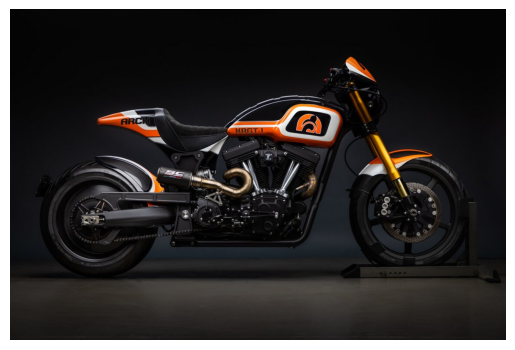


 Method 2: NumPy array slicing 



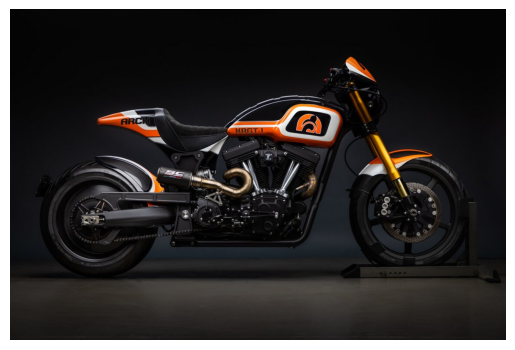

In [53]:
# conversion

rgbtobgr1(test_img)

rgbtobgr2(test_img)

### Resize image

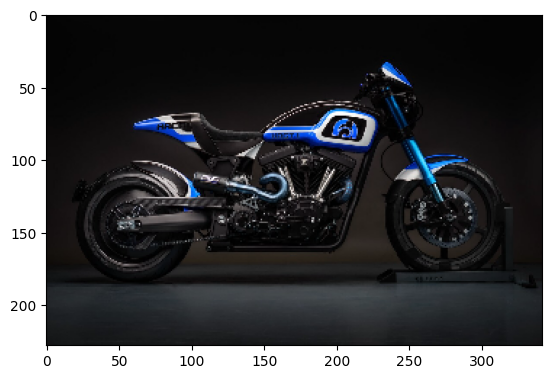

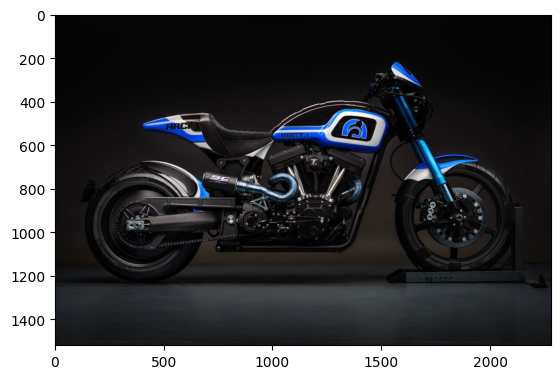

In [54]:
# resize image

imgshrink(test_img)

imgexpand(test_img)

### Image rotation

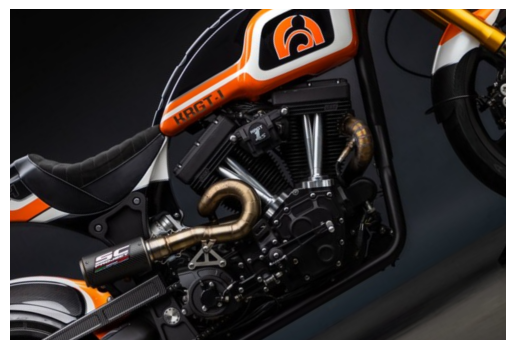

array([[[ 6,  6,  6],
        [ 6,  6,  6],
        [ 6,  6,  6],
        ...,
        [27, 21, 22],
        [33, 28, 27],
        [39, 34, 34]],

       [[ 6,  6,  6],
        [ 6,  6,  6],
        [ 6,  6,  6],
        ...,
        [35, 29, 29],
        [40, 35, 35],
        [42, 39, 37]],

       [[ 6,  6,  6],
        [ 6,  6,  6],
        [ 6,  6,  6],
        ...,
        [42, 37, 36],
        [41, 36, 35],
        [40, 37, 34]],

       ...,

       [[ 5,  5,  5],
        [ 5,  5,  5],
        [ 5,  5,  5],
        ...,
        [63, 59, 56],
        [63, 59, 56],
        [63, 59, 56]],

       [[ 5,  5,  5],
        [ 4,  4,  4],
        [ 4,  4,  4],
        ...,
        [63, 59, 56],
        [62, 58, 55],
        [62, 58, 55]],

       [[ 4,  4,  4],
        [ 3,  3,  3],
        [ 3,  3,  3],
        ...,
        [62, 58, 55],
        [62, 58, 55],
        [62, 58, 55]]], shape=(760, 1140, 3), dtype=uint8)

In [55]:
imgrotate(test_img, 30,2)

### Image Thresholding

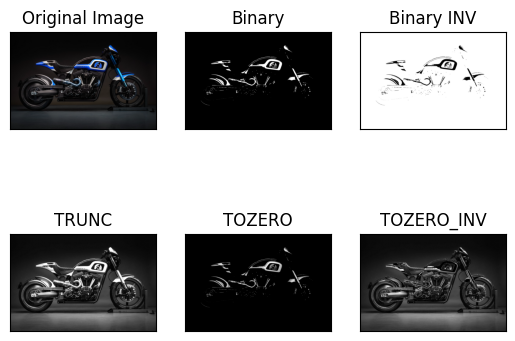

In [56]:
imagethresholding(test_img)

### Image Blurring

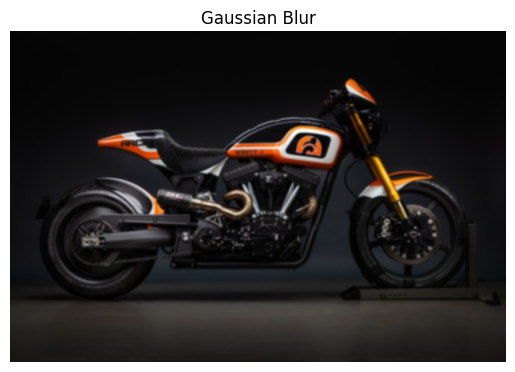

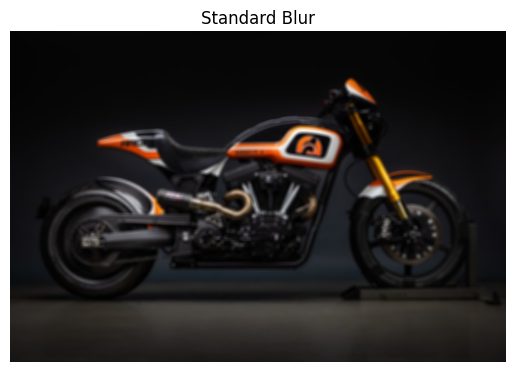

In [57]:
imgblur(test_img)

imgblur(test_img, method='standard', blurkrl=(9,9))

### Image blending with text

Example how to overlay text on the rotated image

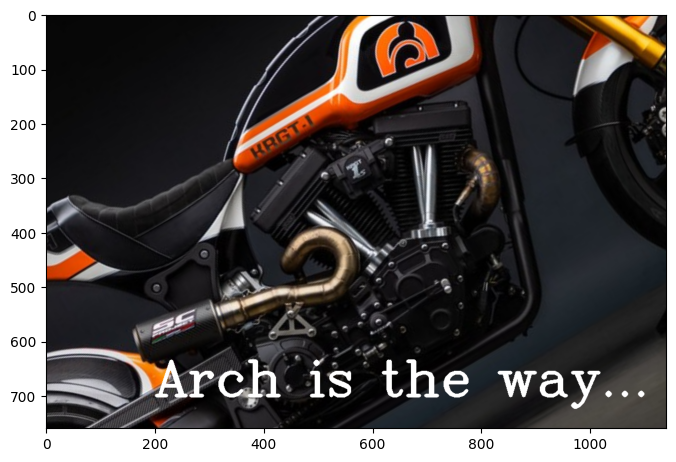

In [58]:

imgr = imgrotate(test_img, 30,2, display=False)
txt = 'Arch is the way...'
imgaddtext(imgr, txt, org=(200,700), color=(255,255,255)) 

## 2.2 Image Feature Detection

### Detect/draw contours on an image


 Number of contours detected: 1460


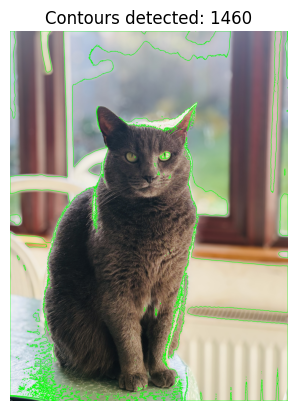


 Number of contours detected: 719


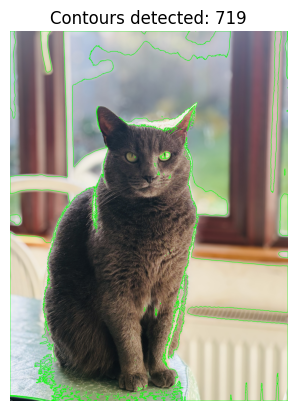

In [59]:
cat_img = "samples/cv/IMG_7744.jpeg"

# default mode RETR_THREE retrieves all contours including nested ones
imgcontours(cat_img, tx=190, br=4)
# only retrieves the outermost contours
imgcontours(cat_img, mode=cv2.RETR_EXTERNAL, tx=190, br=4)

### Sobel
Edge detection

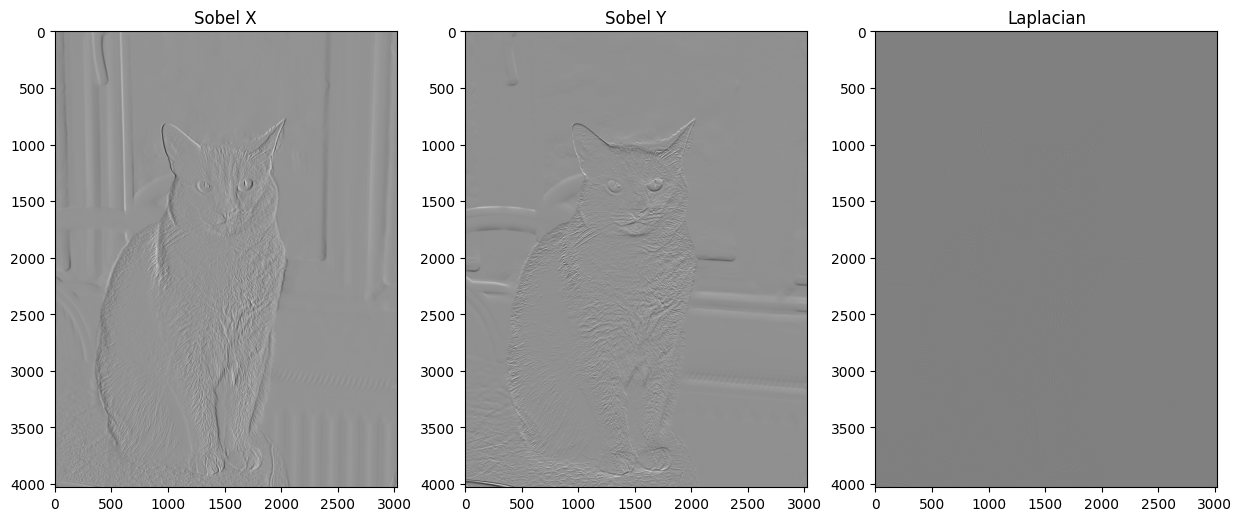

In [60]:
imgedges(cat_img, x=29, y=21)

### Canny

Detecting edges/boundries for text blox images back grounds


 Median value: 255.0


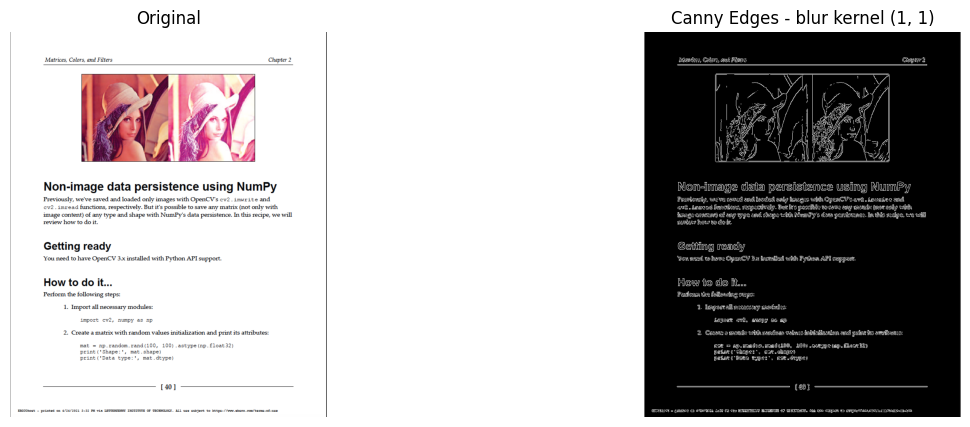

In [61]:
page_img = "samples/cv/Screenshot.png"

imgcanny(page_img, blur_krl=(1,1))

## 2.3 Watershed

isolates foreground objects from the background

using my own functions predifined (all based on lab examples)


 Segments detected: 3


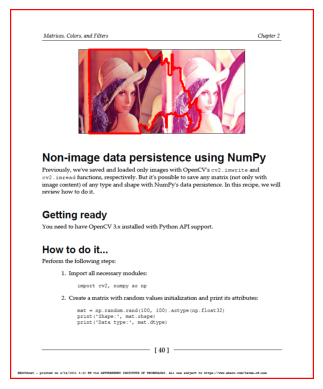

In [62]:

imgwatershed(page_img)

##  2.4 Image enhancment pipline example 

Image sharpening and show histogram (based on something i used in the photohop in the past)

Found 7 files in 'samples/cv/'
['samples/cv/4.jpg', 'samples/cv/IMG_7993.jpg', 'samples/cv/IMG_7994.jpg', 'samples/cv/Screenshot.png', 'samples/cv/Test2.png', 'samples/cv/arch_m.jpg', 'samples/cv/img2025050.jpg']


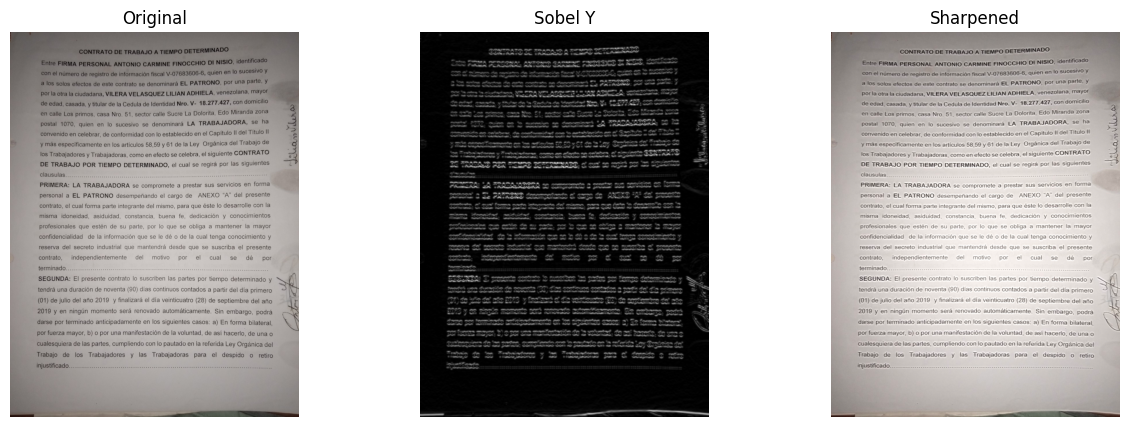

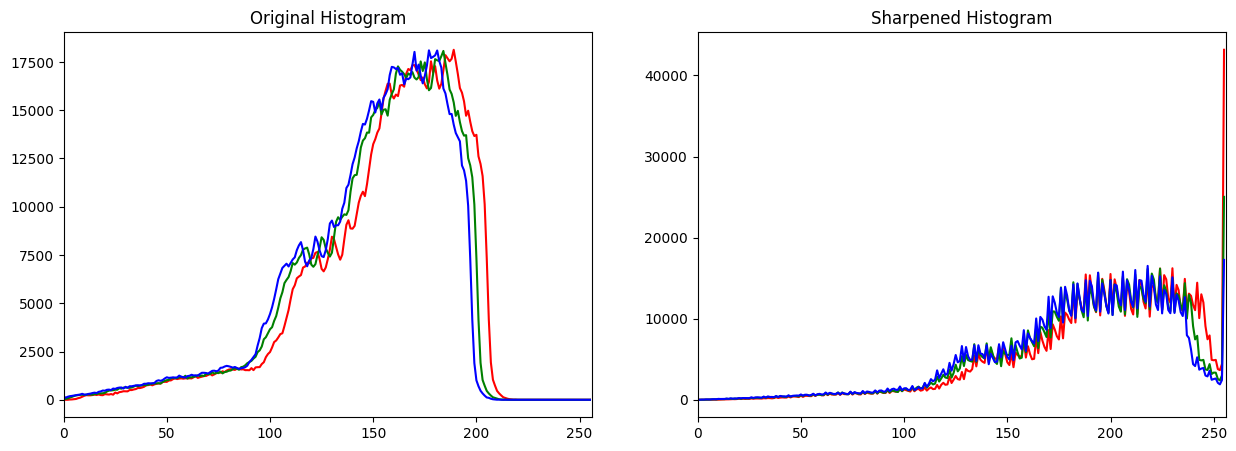

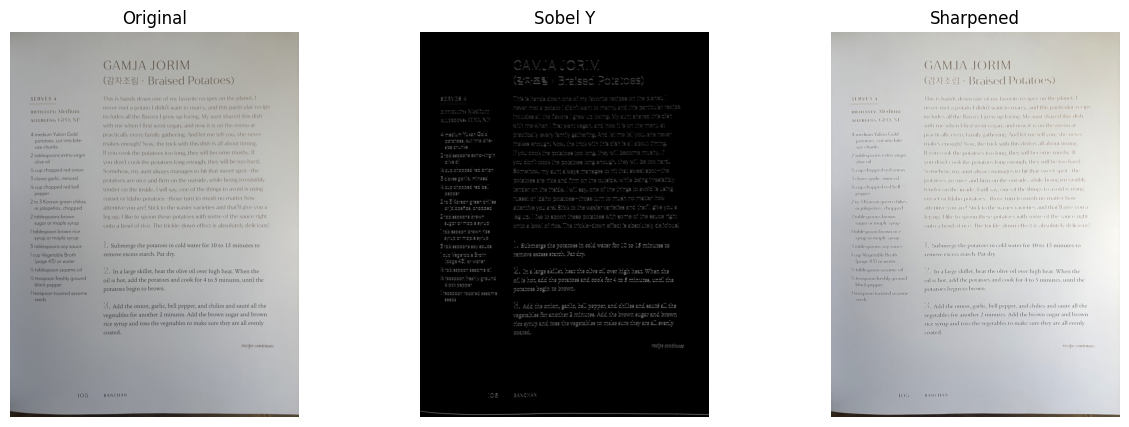

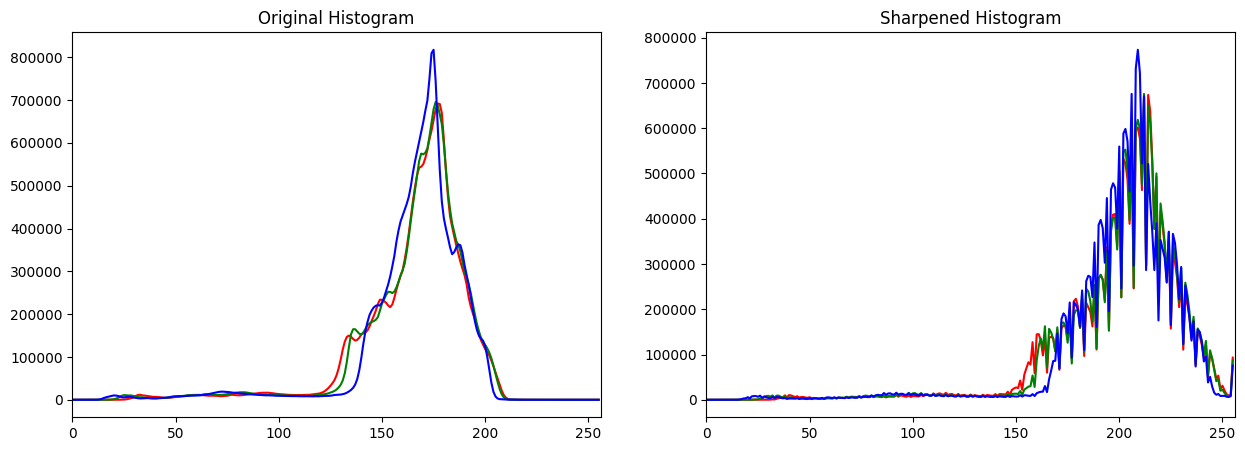

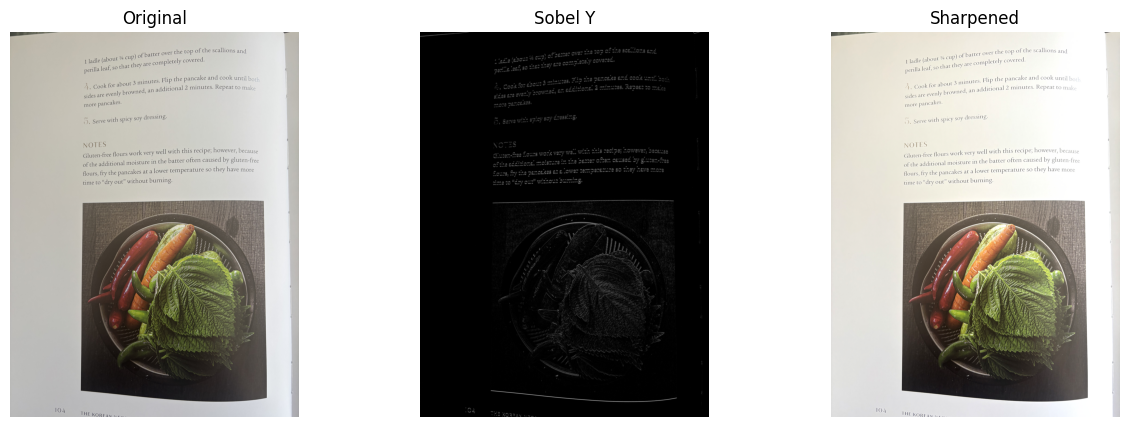

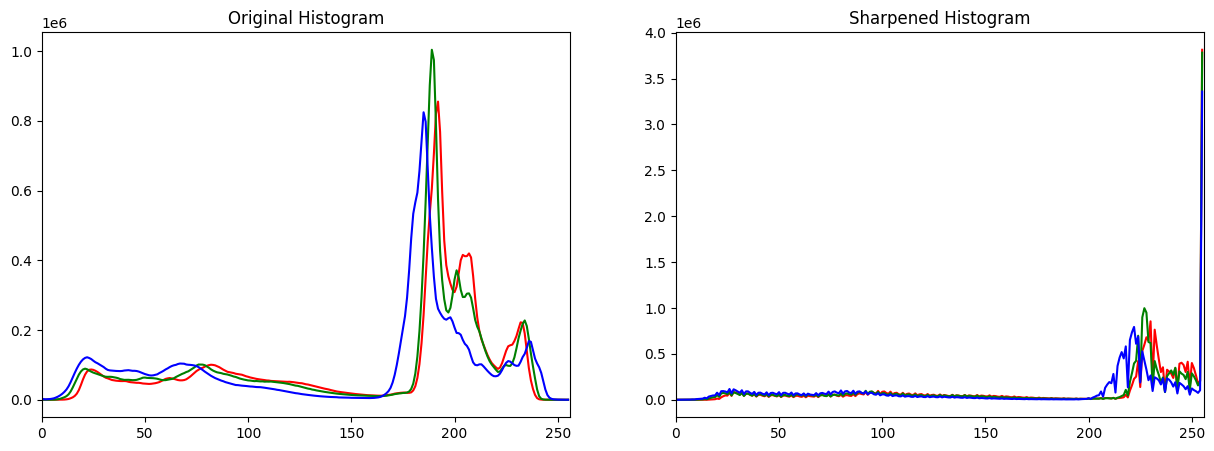

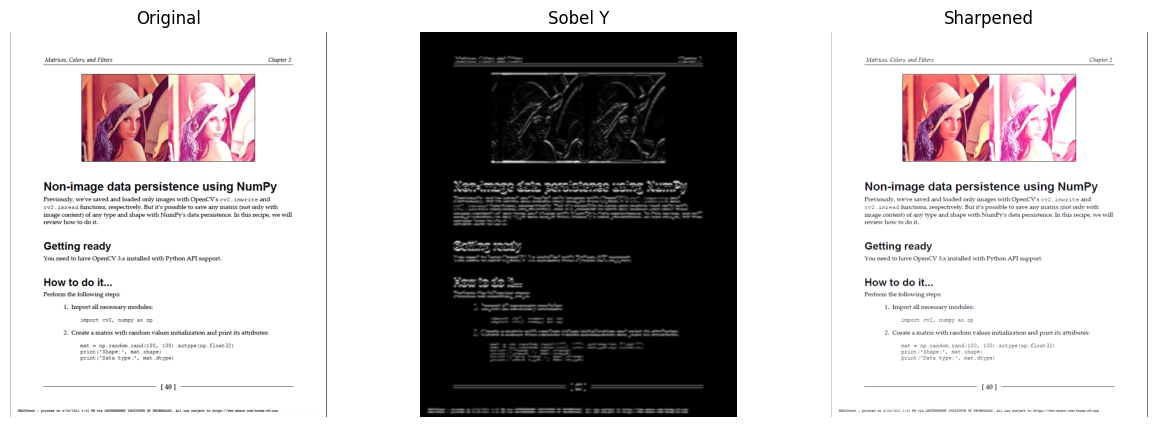

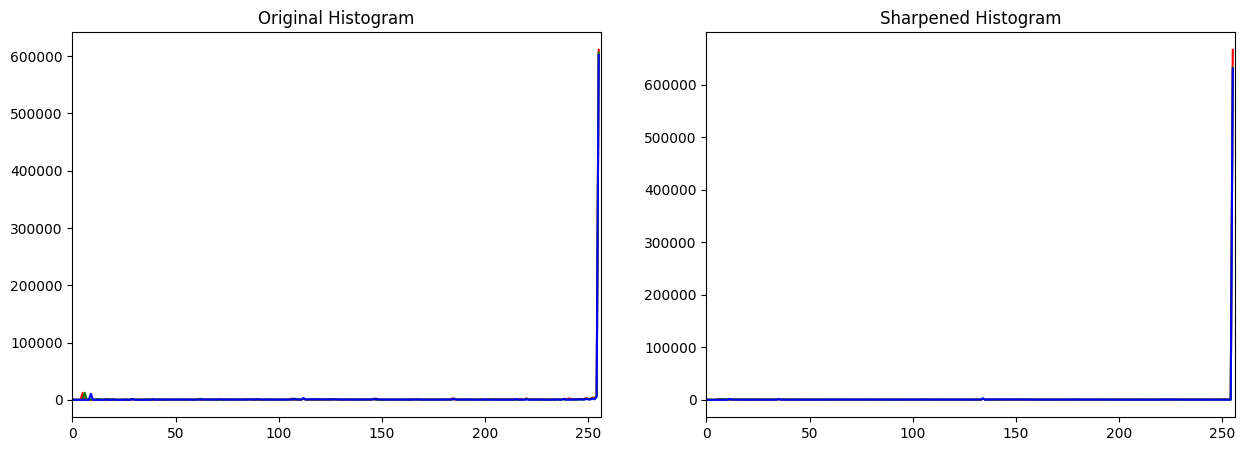

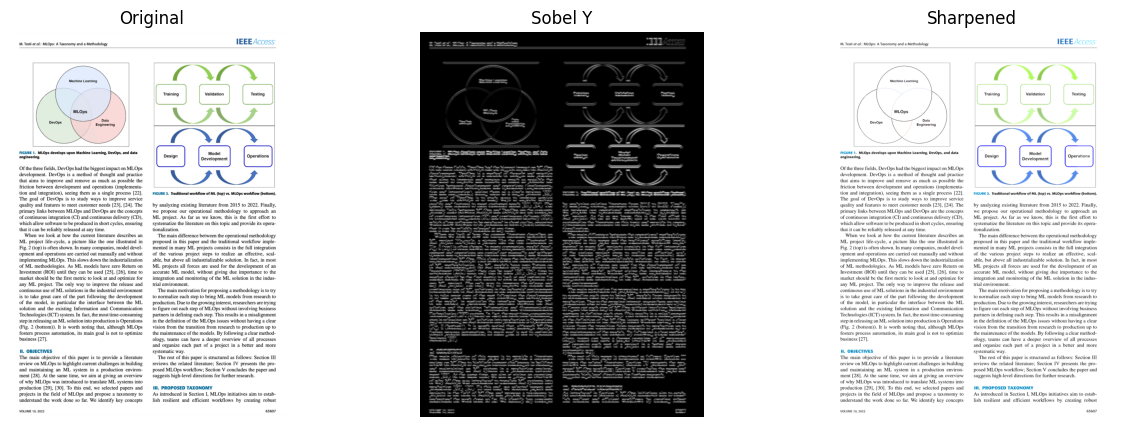

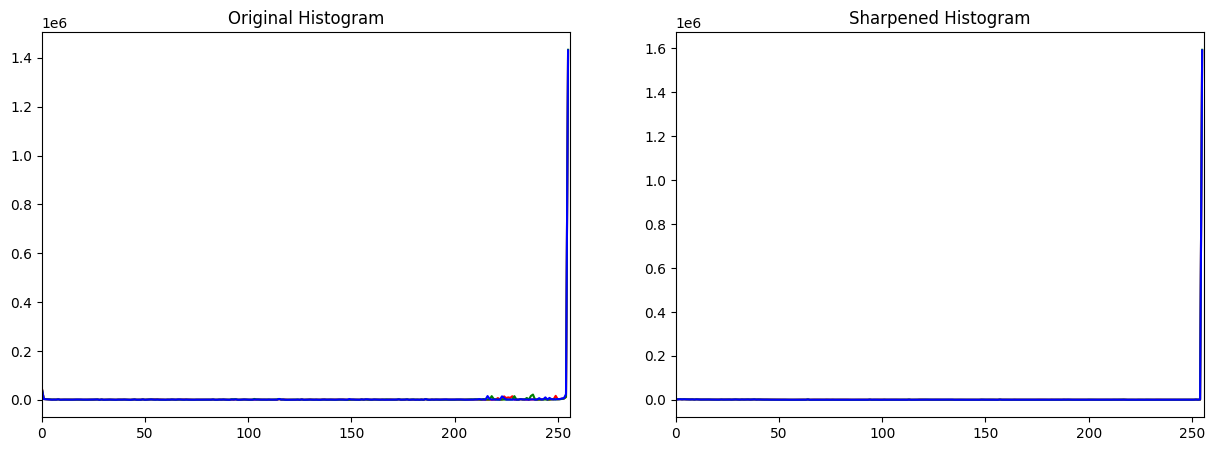

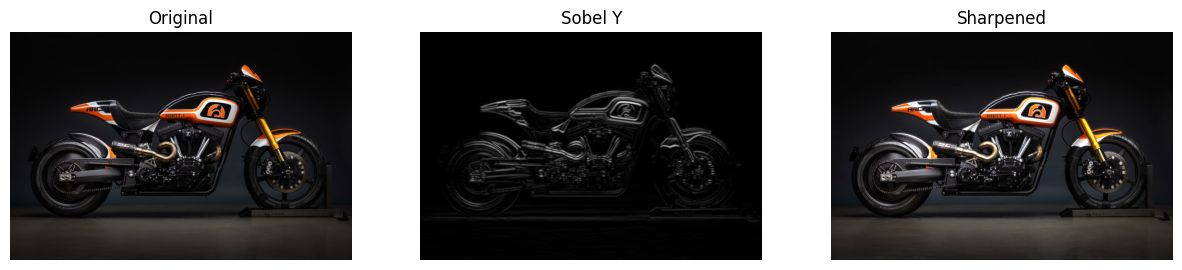

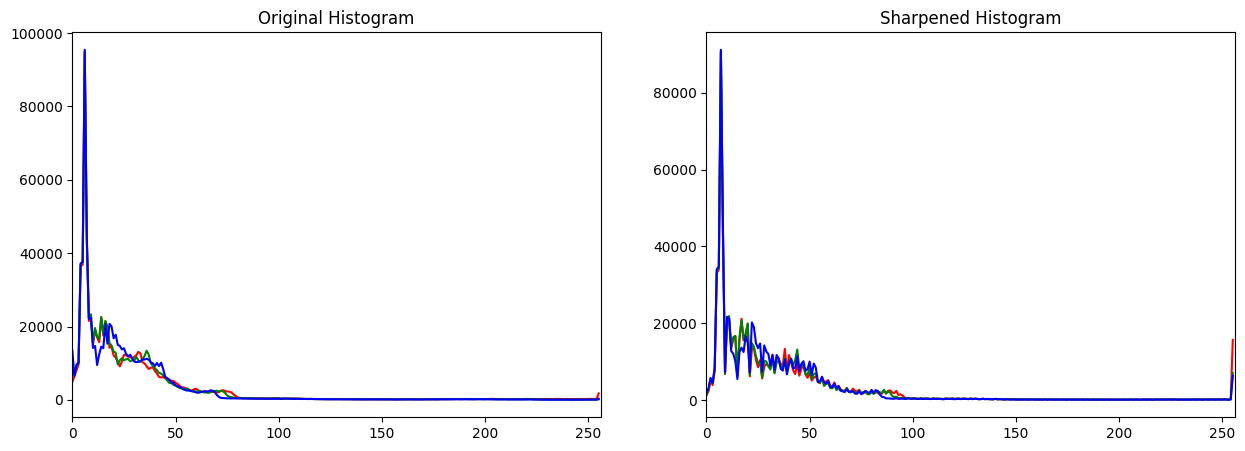

In [ ]:
page_img = "samples/cv/IMG_7994.jpg"

dffiles = load_files("samples/cv/", extensions=['.png', '.jpg'])
print(dffiles)

for d in dffiles:
    imgenhancment(d)




# Multi-modal

## Multi-modal Integration and Insights

In [64]:
# code here

# Final Output

In [65]:
# code